In [1]:
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.metrics import classification_report
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import random
import torch

/home/somitemp/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 3093
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
# cek CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# load data
train_df = pd.read_csv("Data/Training/combined_emotion_dataset.csv")
test_df = pd.read_csv("Data/Testing/test_dataset.csv")

print(train_df.shape, test_df.shape)
print(train_df.columns.tolist())
print(train_df['label'].value_counts())

cuda
(9064, 3) (2029, 3)
['label', 'tweet', 'dataset']
label
Joy        1275
Anger      1135
Sad        1022
anger       991
happy       915
Fear        911
sadness     898
Love        760
fear        584
love        573
Name: count, dtype: int64


In [4]:
print(train_df['label'].unique())
print()
print(test_df['label'].unique())

<ArrowStringArray>
[  'happy',   'anger',    'fear', 'sadness',    'love',   'Anger',     'Sad',
    'Love',     'Joy',    'Fear']
Length: 10, dtype: str

<ArrowStringArray>
['sadness', 'love', 'joy', 'anger', 'fear']
Length: 5, dtype: str


In [5]:
train_df = pd.read_csv("Data/Training/training_dataset.csv")
test_df = pd.read_csv("Data/Testing/test_dataset.csv")

print(train_df.shape, test_df.shape)
print(train_df['label'].value_counts())

(9064, 3) (2029, 3)
label
joy        2190
anger      2126
sadness    1920
fear       1495
love       1333
Name: count, dtype: int64


In [6]:
# label encoding
label2id = {'anger': 0, 'fear': 1, 'joy': 2, 'love': 3, 'sadness': 4}
id2label = {v: k for k, v in label2id.items()}

train_df['label_id'] = train_df['label'].map(label2id)
test_df['label_id'] = test_df['label'].map(label2id)

# load tokenizer
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")
print("Tokenizer loaded.")

Tokenizer loaded.


In [7]:
class EmotionDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts = df['tweet'].tolist()
        self.labels = df['label_id'].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# buat dataset dan dataloader
train_dataset = EmotionDataset(train_df, tokenizer)
test_dataset = EmotionDataset(test_df, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 567
Test batches: 127


In [8]:
from transformers import AutoModelForSequenceClassification

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

model = AutoModelForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p1",
    num_labels=5,
    id2label=id2label,
    label2id=label2id
)
model = model.to(device)
print("Model loaded.")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 25353.62it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded.


In [9]:
from transformers import get_linear_schedule_with_warmup

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

EPOCHS = 5
total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print(f"Total training steps: {total_steps}")

Total training steps: 2835


In [10]:
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(list(label2id.values())),
    y=train_df['label_id'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

print(class_weights)

[0.85268109 1.21257525 0.82776256 1.35993998 0.94416667]


# Training Loop

## Step 1 -- Training dan Validasi

### Data Splitting (80:20)

In [11]:
from sklearn.model_selection import train_test_split

# 80:20 split untuk tahap 1
train_sub, val_sub = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['label_id'])

train_sub_dataset = EmotionDataset(train_sub, tokenizer)
val_dataset = EmotionDataset(val_sub, tokenizer)

train_sub_loader = DataLoader(train_sub_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print(f"Train subset: {len(train_sub)}, Val: {len(val_sub)}")

Train subset: 7251, Val: 1813


### Training dan Validasi

In [ ]:
# def evaluate(model, loader, loss_fn):
#     model.eval()
#     all_preds, all_labels = [], []
#     total_loss = 0
#     with torch.no_grad():
#         for batch in loader:
#             input_ids = batch['input_ids'].to(device)
#             attention_mask = batch['attention_mask'].to(device)
#             labels = batch['labels'].to(device)

#             outputs = model(input_ids=input_ids, attention_mask=attention_mask)
#             loss = loss_fn(outputs.logits, labels)
#             total_loss += loss.item()
#             preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
#             all_preds.extend(preds)
#             all_labels.extend(labels.cpu().numpy())

#     f1 = f1_score(all_labels, all_preds, average='macro')
#     avg_loss = total_loss / len(loader)
#     return avg_loss, f1

In [12]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='macro')
    avg_loss = total_loss / len(loader)
    return avg_loss, f1

In [13]:
from sklearn.metrics import f1_score
import numpy as np

EPOCHS = 50
PATIENCE = 5

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_sub_loader) * 5
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

best_f1 = 0
best_epoch = 0
epochs_no_improve = 0

history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0

    for batch in tqdm(train_sub_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_sub_loader)
    val_loss, val_f1 = evaluate(model, val_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)

    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_epoch = epoch + 1
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model_stage1_50ep.pt")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping di epoch {epoch+1} (no improvement selama {PATIENCE} epoch)")
        break

print(f"\nBest epoch: {best_epoch} dengan Val F1: {best_f1:.4f}")

Epoch 1/50: 100%|██████████| 454/454 [01:51<00:00,  4.08it/s]


Epoch 1 | Train Loss: 0.8536 | Val Loss: 0.5687 | Val F1: 0.8019


Epoch 2/50: 100%|██████████| 454/454 [01:57<00:00,  3.87it/s]


Epoch 2 | Train Loss: 0.4376 | Val Loss: 0.5846 | Val F1: 0.8020


Epoch 3/50: 100%|██████████| 454/454 [01:58<00:00,  3.82it/s]


...

Epoch 8 | Train Loss: 0.0280 | Val Loss: 0.9606 | Val F1: 0.8106


Epoch 9/50: 100%|██████████| 454/454 [02:02<00:00,  3.70it/s]


Epoch 9 | Train Loss: 0.0290 | Val Loss: 0.9606 | Val F1: 0.8106


Epoch 10/50: 100%|██████████| 454/454 [02:01<00:00,  3.74it/s]


Epoch 10 | Train Loss: 0.0296 | Val Loss: 0.9606 | Val F1: 0.8106

Early stopping di epoch 10 (no improvement selama 5 epoch)

Best epoch: 5 dengan Val F1: 0.8106


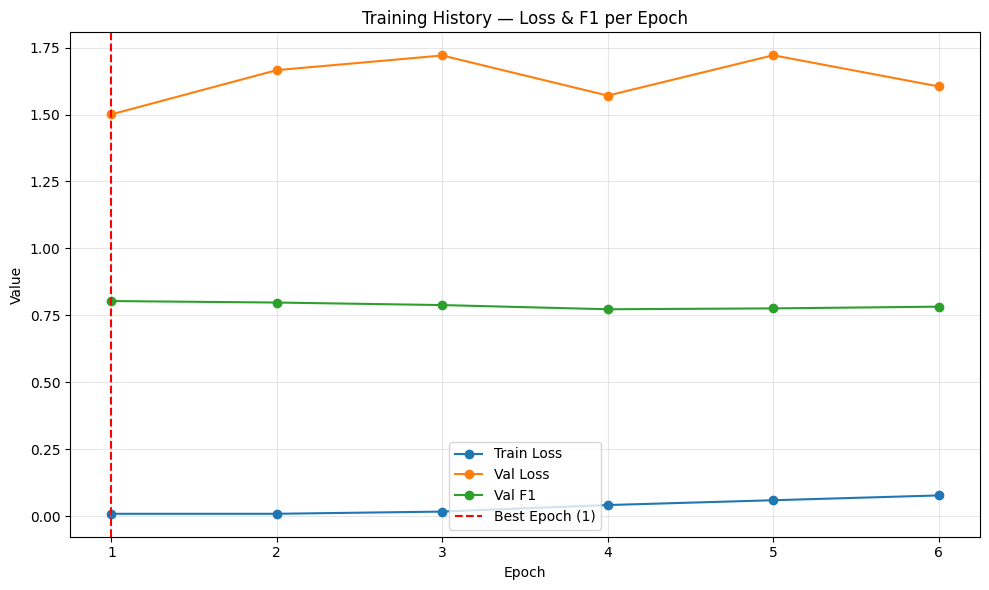

In [17]:
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Val Loss', marker='o')
plt.plot(epochs_range, history['val_f1'], label='Val F1', marker='o')
plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Training History — Loss & F1 per Epoch')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("training_history.png", dpi=150)
plt.show()

### Evaluasi in-domain

In [13]:
from sklearn.metrics import accuracy_score


In [14]:
model.load_state_dict(torch.load("best_model_stage1.pt"))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"In-Domain Accuracy (Epoch 3 - Best): {acc:.4f}\n")
print(classification_report(all_labels, all_preds, target_names=list(label2id.keys())))

In-Domain Accuracy (Epoch 3 - Best): 0.8119

              precision    recall  f1-score   support

       anger       0.85      0.83      0.84       425
        fear       0.83      0.87      0.85       299
         joy       0.83      0.79      0.81       438
        love       0.79      0.79      0.79       267
     sadness       0.75      0.79      0.77       384

    accuracy                           0.81      1813
   macro avg       0.81      0.81      0.81      1813
weighted avg       0.81      0.81      0.81      1813



## Step 2 -- Reset model dan train ulang pakai full dataset dengan epoch=3

In [23]:
# reset model
model2 = AutoModelForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p1",
    num_labels=5,
    id2label=id2label,
    label2id=label2id
)
model2 = model2.to(device)

BEST_EPOCH = 3

optimizer2 = AdamW(model2.parameters(), lr=2e-5, weight_decay=0.01)
total_steps2 = len(train_loader) * BEST_EPOCH
scheduler2 = get_linear_schedule_with_warmup(optimizer2,
                                              num_warmup_steps=int(0.1 * total_steps2),
                                              num_training_steps=total_steps2)

for epoch in range(BEST_EPOCH):
    model2.train()
    total_train_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{BEST_EPOCH}"):
        optimizer2.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model2(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model2.parameters(), 1.0)
        optimizer2.step()
        scheduler2.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{BEST_EPOCH} | Train Loss: {avg_train_loss:.4f}")

torch.save(model2.state_dict(), "final_model.pt")
print("Model saved: final_model.pt")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 36090.56it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Epoch 1/3: 100%|██████████| 567/567 [02:17<00:00,  4.13it/s]


Epoch 1/3 | Train Loss: 0.7805


Epoch 2/3: 100%|██████████| 567/567 [02:34<00:00,  3.67it/s]


Epoch 2/3 | Train Loss: 0.3756


Epoch 3/3: 100%|██████████| 567/567 [02:47<00:00,  3.38it/s]


Epoch 3/3 | Train Loss: 0.1789
Model saved: final_model.pt


# Evaluasi Model - Test Set (Cross-Domain)

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

val_loss, test_f1 = evaluate(model2, test_loader)

# detail per kelas
model2.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model2(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=list(label2id.keys())))
print(f"\nMacro F1: {test_f1:.4f}")

              precision    recall  f1-score   support

       anger       0.74      0.33      0.46       410
        fear       0.44      0.60      0.51       164
         joy       0.24      0.72      0.35       250
        love       0.81      0.20      0.32       673
     sadness       0.56      0.73      0.63       532

    accuracy                           0.46      2029
   macro avg       0.56      0.51      0.45      2029
weighted avg       0.63      0.46      0.45      2029


Macro F1: 0.4539


In [25]:
acc = accuracy_score(all_labels, all_preds)
print(f"Accuracy: {acc:.4f}\n")

Accuracy: 0.4603



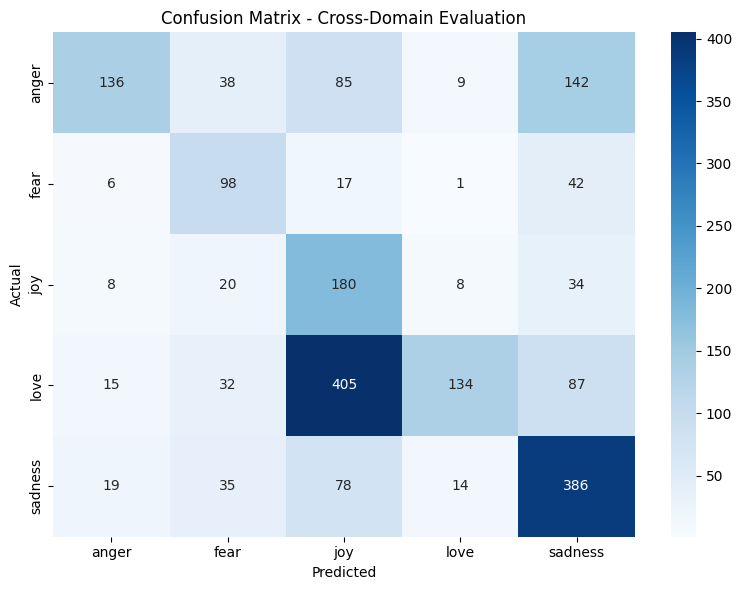

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(label2id.keys()),
            yticklabels=list(label2id.keys()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Cross-Domain Evaluation')
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

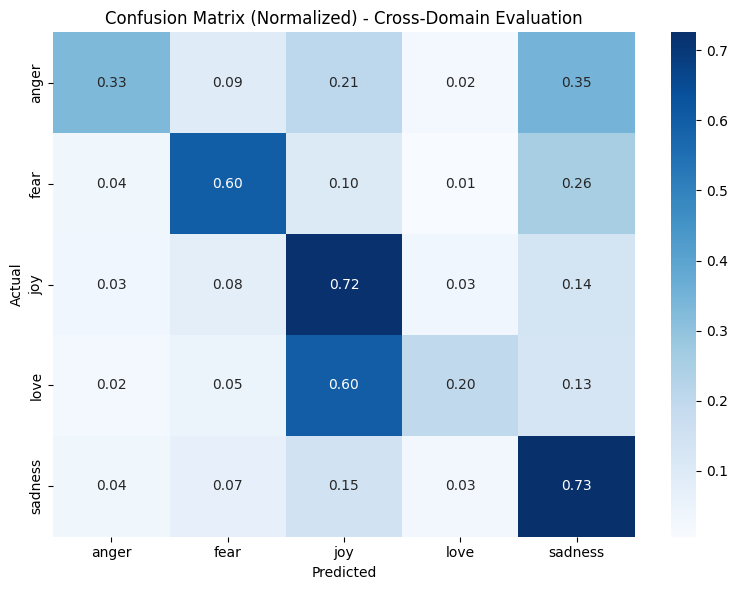

In [27]:
cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=list(label2id.keys()),
            yticklabels=list(label2id.keys()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Normalized) - Cross-Domain Evaluation')
plt.tight_layout()
plt.savefig("confusion_matrix_normalized.png", dpi=150)
plt.show()

In [19]:
print(train_df.shape)
print(train_df['label'].value_counts())

(9064, 4)
label
joy        2190
anger      2126
sadness    1920
fear       1495
love       1333
Name: count, dtype: int64


In [22]:
print(test_df.shape)
print(test_df['label'].value_counts())

(2029, 4)
label
love       673
sadness    532
anger      410
joy        250
fear       164
Name: count, dtype: int64


In [21]:
for name, param in model2.named_parameters():
    if 'classifier' in name:
        print(name, param.data.mean().item(), param.data.std().item())

classifier.weight 0.00021684473904315382 0.020053761079907417
classifier.bias 0.0 0.0
